In [180]:
import pandas as pd
import numpy as np

trades_df = pd.read_parquet('../data/trades/congress_trades_full.parquet')

lobby_df = pd.read_parquet('../data/lobbying/lobbying_data.parquet')

In [99]:
trades_df_og_shape = trades_df.shape

lobby_df_og_shape = lobby_df.shape

In [100]:
trades_df.isnull().mean()

Ticker                0.000000
TickerType            0.600645
Company               1.000000
Traded                0.000000
Transaction           0.000000
Trade_Size_USD        0.000000
Status                1.000000
Subholding            1.000000
Description           0.949530
Name                  0.000000
BioGuideID            0.000000
Filed                 0.000000
Party                 0.000000
District              0.584613
Chamber               0.000000
Comments              1.000000
Quiver_Upload_Time    1.000000
excess_return         0.078664
State                 1.000000
last_modified         0.000765
TradeDate             0.000000
dtype: float64

In [181]:
trades_df = trades_df.dropna(thresh = trades_df.shape[0]*0.1, axis = 1)

lobby_df = lobby_df.dropna(thresh = lobby_df.shape[0]*0.1, axis = 1)

In [111]:
print(f'column removed from trades--> {trades_df_og_shape[1] - trades_df.shape[1]}' )

print(f'column removed from lobby_df--> {lobby_df_og_shape[1] - lobby_df.shape[1]}' )

print(f'new shape: trade --> {trades_df.shape}')
print(f'new shape: lobby_df --> {lobby_df.shape}')

column removed from trades--> 7
column removed from lobby_df--> 0
new shape: trade --> (109847, 14)
new shape: lobby_df --> (16314, 7)


In [184]:


trades_df['Trade_Size_USD'] = trades_df['Trade_Size_USD'].str.strip()
trades_df['Trade_Size_USD'] = trades_df['Trade_Size_USD'].str.extract(r'(\d+\.?\d*)')

trades_df['Trade_Size_USD'] = trades_df['Trade_Size_USD'].astype(float)

In [ ]:
trades_df['Trade_Size_USD'].value_counts()

#most common number is 80617

Trade_Size_USD
1001      80617
15001     17282
50001      6228
100001     3869
250001      787
          ...  
567           1
512           1
817           1
636           1
319           1
Name: count, Length: 339, dtype: int64

In [144]:
trades_df.Transaction.value_counts()

Transaction
Purchase    55537
Sale        53682
Exchange      628
Name: count, dtype: int64

In [185]:
trades_df['Transaction'] = trades_df['Transaction'].str.capitalize()
trades_df['Transaction'] = trades_df['Transaction'].str.replace(' (full)','')
trades_df['Transaction'] = trades_df['Transaction'].str.replace('(partial)','')
trades_df['Transaction'] = trades_df['Transaction'].str.strip()

#Purchase    55537
#Sale        53682
#Exchange      628

In [186]:
#Traded 

#Filed 

#trades_df['Traded'].to_datetime()

trades_df['Traded'] = pd.to_datetime(trades_df['Traded'], format='%Y-%m-%d', errors = 'raise')
trades_df['Filed'] = pd.to_datetime(trades_df['Filed'], format='%Y-%m-%d', errors = 'raise')


trades_df['days_to_file'] = trades_df['Filed'] - trades_df['Traded']

trades_df['days_to_file'].value_counts()

trades_df['days_to_file'].describe()

#mean = 48 days
#there are some negative numbers, it means that they were disclosed before they were done, with is impossible. should be removed


count                      109847
mean      48 days 13:08:41.121195
std      121 days 04:22:09.895431
min           -357 days +00:00:00
25%              18 days 00:00:00
50%              28 days 00:00:00
75%              37 days 00:00:00
max            3929 days 00:00:00
Name: days_to_file, dtype: object

In [187]:
lobby_df.Amount.value_counts()

lobby_df.Amount.isnull().sum()

lobby_df['Amount'] = lobby_df['Amount'].astype(float)

lobby_df[lobby_df['Amount'].isnull()]['Ticker'].value_counts()

#Q1.5 I would fill it up with the average number that is based on the same ticker. if there are no similar ticker, i would drop it

Ticker
KT      18
KMI     14
KO       9
ACM      7
AMRC     7
AIZ      5
AMGN     5
AFL      4
AAL      3
ALB      2
ABT      1
ACAD     1
ADSK     1
AGN      1
AGR      1
ALE      1
KLAC     1
Name: count, dtype: int64

In [190]:
print(lobby_df[lobby_df['Amount'].isnull()].shape)

lobby_df['Amount'] = lobby_df['Amount'].fillna(lobby_df.groupby(['Ticker'])['Amount'].transform('median'))

lobby_df[lobby_df['Amount'].isnull()].shape

(81, 7)


(0, 7)

In [206]:
trades_df.groupby(['Name','Party','Chamber'])['Ticker'].count().sort_values(ascending = False).head(10)

Name               Party  Chamber        
Ro Khanna          D      Senate             27079
Michael T. McCaul  R      Senate             24480
Josh Gottheimer    D      Representatives     3456
Thomas Macarthur   R      Representatives     2758
David Perdue       R      Senate              2242
Gilbert Cisneros   D      Representatives     1914
Lisa Mcclain       R      Representatives     1394
Lois Frankel       D      Representatives     1358
Greg Gianforte     R      Representatives     1331
Susie Lee          D      Representatives     1280
Name: Ticker, dtype: int64

In [215]:
trades_df['traded_year'] = trades_df['Traded'].dt.isocalendar()['year']

In [239]:
years_df = pd.DataFrame(trades_df.groupby(['traded_year'])['Ticker'].count()).reset_index()
years_df.columns = ['Year','Trades']
years_df

,Year,Trades
0,2012,9
1,2013,372
2,2014,5217
3,2015,5964
4,2016,7151
5,2017,8769
6,2018,11500
7,2019,11065
8,2020,12110
9,2021,7253


In [240]:
trades_df.Transaction.value_counts()

Sales_df = trades_df[trades_df['Transaction'] == 'Sale']

years_Sales_df = pd.DataFrame(Sales_df.groupby(['traded_year'])['Ticker'].count()).reset_index()
years_Sales_df.columns = ['Year','Sales']

Purchase_df = trades_df[trades_df['Transaction'] == 'Purchase']

years_Purchase_df = pd.DataFrame(Purchase_df.groupby(['traded_year'])['Ticker'].count()).reset_index()
years_Purchase_df.columns = ['Year','Purchases']




In [241]:
years_df = years_df.merge(years_Sales_df, how = 'left', on = 'Year' ).merge(years_Purchase_df, how = 'left', on = 'Year' )

years_df

,Year,Trades,Sales,Purchases
0,2012,9,5,4
1,2013,372,223,145
2,2014,5217,2431,2767
3,2015,5964,3209,2700
4,2016,7151,3200,3870
5,2017,8769,4018,4712
6,2018,11500,5125,6321
7,2019,11065,5684,5342
8,2020,12110,5717,6327
9,2021,7253,3654,3526


In [243]:
years_df['ratio'] = years_df['Purchases']/years_df['Sales']
years_df

,Year,Trades,Sales,Purchases,ratio
0,2012,9,5,4,0.800000
1,2013,372,223,145,0.650224
2,2014,5217,2431,2767,1.138215
3,2015,5964,3209,2700,0.841384
4,2016,7151,3200,3870,1.209375
5,2017,8769,4018,4712,1.172723
6,2018,11500,5125,6321,1.233366
7,2019,11065,5684,5342,0.939831
8,2020,12110,5717,6327,1.106699
9,2021,7253,3654,3526,0.964970


In [ ]:
tickerslobby_df

,Date,Amount,Client,Issue,Specific_Issue,Registrant,Ticker
0,1999-08-19,0.0,AGILENT TECHNOLOGIES INC,Government Issues,,HALE & DORR,A
1,2000-02-17,0.0,AGILENT TECHNOLOGIES INC,Government Issues,,HALE & DORR,A
2,2000-03-14,0.0,AGILENT TECHNOLOGIES INC,Labor Issues/Antitrust/Workplace \n Medical/Di...,,"AGILENT TECHNOLOGIES, INC",A
3,2000-08-10,80000.0,AGILENT TECHNOLOGIES INC,Education \n Labor Issues/Antitrust/Workplace ...,,"AGILENT TECHNOLOGIES, INC",A
4,2000-08-14,0.0,AGILENT TECHNOLOGIES,Trade (domestic/foreign) \n Health Issues \n M...,,BERGNER BOCKORNY CASTAGNETTI HAWKINS & BRAIN,A
...,...,...,...,...,...,...,...
16309,2021-04-20,30000.0,LAUREATE EDUCATION INC (FKA LAUREATE INTERNATI...,NaN,NaN,AKIN GUMP STRAUSS HAUER & FELD,LAUR
16310,2021-04-20,30000.0,LAUREATE EDUCATION,Budget/Appropriations \n Education,"Public Law 117-2, American Rescue Plan Act of ...",PENN HILL GROUP,LAUR
16311,2021-07-20,30000.0,LAUREATE EDUCATION,NaN,NaN,PENN HILL GROUP,LAUR
16312,2021-09-29,30000.0,LAUREATE EDUCATION,Budget/Appropriations \n Education,"Public Law 116-136, Coronavirus Aid, Relief, a...",PENN HILL GROUP,LAUR


In [264]:
new_trades_df = trades_df[(trades_df['days_to_file'].astype(int) <= 30)]

In [259]:
trades_df['days_to_file'] = trades_df['days_to_file'].astype(str).str.extract(r'(\d+\.?\d*)').astype(int)

In [267]:
new_trades_df.shape

new_trades_df.Transaction.value_counts()/new_trades_df.shape[0]

Transaction
Purchase    0.504566
Sale        0.491622
Exchange    0.003812
Name: count, dtype: float64

In [268]:
import pandas as pd
import matplotlib.pyplot as plt


<Axes: xlabel='Trade_Size_USD'>

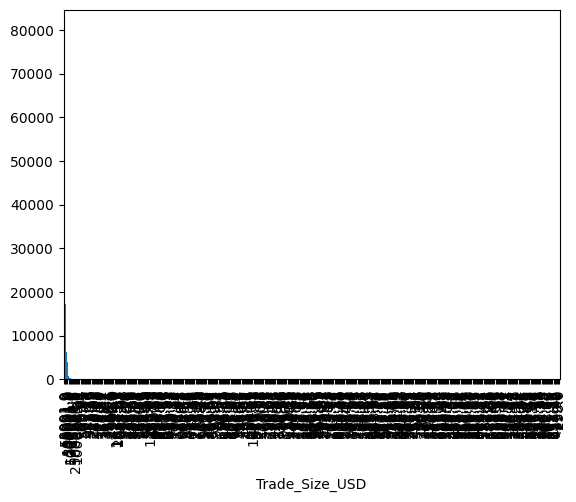

In [271]:
#trades_df['Trade_Size_USD'].value_counts()

trades_df['Trade_Size_USD'].value_counts().plot(kind='bar')          

In [274]:
#q3.1 yes log would help, as a form of scaler

trades_df.columns

trades_df['excess_return'] = trades_df['excess_return'].astype(float)

In [278]:
trades_df.groupby(['Party'])['excess_return'].mean()


Party
D    -8.895244
I   -52.479780
R   -23.117087
Name: excess_return, dtype: float64

In [277]:

trades_df.groupby(['Transaction'])['excess_return'].mean()

Transaction
Exchange    -9.725784
Purchase   -10.812269
Sale       -21.275030
Name: excess_return, dtype: float64

In [279]:

trades_df.groupby(['Party','Transaction'])['excess_return'].mean()

Party  Transaction
D      Exchange       -7.243483
       Purchase       -5.241787
       Sale          -12.828616
I      Exchange      -70.660878
       Purchase      -31.489576
       Sale          -79.620019
R      Exchange      -11.235455
       Purchase      -16.746825
       Sale          -29.630337
Name: excess_return, dtype: float64

In [ ]:
trades_df.columns

#Q3.4 trade_size or days_to_file 

Index(['Ticker', 'TickerType', 'Traded', 'Transaction', 'Trade_Size_USD',
       'Name', 'BioGuideID', 'Filed', 'Party', 'District', 'Chamber',
       'excess_return', 'last_modified', 'TradeDate', 'days_to_file',
       'traded_year'],
      dtype='str')

In [287]:
#For each unique ticker, compute: total trade volume, number of distinct politicians who traded it, average excess_return, and total lobbying spend. 
#Produce a single summary DataFrame sorted by total lobbying spend descending. What are the top 5 tickers?

ticker_sum_df = pd.DataFrame(trades_df.groupby(['Ticker'])['Trade_Size_USD'].sum()).reset_index()
politician_count_df = pd.DataFrame(trades_df[['Ticker','BioGuideID']].drop_duplicates().groupby(['Ticker'])['BioGuideID'].count()).reset_index()
exreturn_avg_df = pd.DataFrame(trades_df.groupby(['Ticker'])['excess_return'].mean()).reset_index()
lobby_spent_df = pd.DataFrame(lobby_df.groupby(['Ticker'])['Amount'].sum()).reset_index()


In [288]:
ticker_sum_df = ticker_sum_df.merge(politician_count_df,how = 'left', on = 'Ticker').merge(exreturn_avg_df,how = 'left', on = 'Ticker').merge(lobby_spent_df,how = 'left', on = 'Ticker')

In [293]:
ticker_sum_df.sort_values(by = 'Amount', ascending = False)

,Ticker,Trade_Size_USD,BioGuideID,excess_return,Amount
280,AMGN,1657216.0,48,-38.596337,3.135403e+08
62,AAL,1477094.0,15,-107.039191,1.704196e+08
163,AFL,476076.0,16,27.108728,1.611155e+08
88,ABT,4277309.0,52,-59.281717,1.603347e+08
146,AEP,130060.0,19,-54.645937,1.553152e+08
...,...,...,...,...,...
5061,ZU,1001.0,1,46.074388,NaN
5062,ZUO,67011.0,2,-125.347511,NaN
5063,ZURVY,19005.0,3,-7.638394,NaN
5064,^MWE,1001.0,1,NaN,NaN
